In [1]:
from pathlib import Path
import glob

from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from thomas2024.calibration import assemble_thresholds, lookup_pop_at_risk, lookup_pop_exposed


display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

In [2]:
storm_set_params = {
    "STORM_constant": ("STORM", 2000, None, None),
    "STORM_CNRM-CM6-1-HR": ("STORM", 2050, "RCP8.5", "CNRM"),
    "STORM_CMCC-CM2-VHR4": ("STORM", 2050, "RCP8.5", "CMCC"),
    "STORM_EC-Earth3P-HR": ("STORM", 2050, "RCP8.5", "EC-Earth"),
    "STORM_HadGEM3-GC31-HM": ("STORM", 2050, "RCP8.5", "HadGEM3"),

    "IRIS_PRESENT": ("IRIS", 2000, None, None),
    "IRIS_SSP5-2050": ("IRIS", 2050, "SSP5-8.5", None),

    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2010": ("CHAZ", 2010, None, "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2010": ("CHAZ", 2010, None, "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2010": ("CHAZ", 2010, None, "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2010": ("CHAZ", 2010, None, "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2010": ("CHAZ", 2010, None, "MIROC6"),
    "CHAZ_SSP-585_GCM-UKESM1-0-LL_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "UKESM1"),
    "CHAZ_SSP-585_GCM-CESM2_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CESM2"),
    "CHAZ_SSP-585_GCM-CNRM-CM6-1_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "CNRM"),
    "CHAZ_SSP-585_GCM-EC-Earth3_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "EC-Earth3"),
    "CHAZ_SSP-585_GCM-MIROC6_epoch-2050": ("CHAZ", 2050, "SSP5-8.5", "MIROC6"),

    "emanuel_ssp-585_gcm-cesm2_epoch-2005": ("Emanuel", 2005, None, "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2005": ("Emanuel", 2005, None, "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2005": ("Emanuel", 2005, None, "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2005": ("Emanuel", 2005, None, "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2005": ("Emanuel", 2005, None, "UKMO6"),
    "emanuel_ssp-585_gcm-cesm2_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CESM2"),
    "emanuel_ssp-585_gcm-cnrm6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "CNRM6"),
    "emanuel_ssp-585_gcm-ecearth6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "EC-Earth6"),
    "emanuel_ssp-585_gcm-miroc6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "MIROC6"),
    "emanuel_ssp-585_gcm-ukmo6_epoch-2050": ("Emanuel", 2050, "SSP5-8.5", "UKMO6"),
}

group_colours = {
    "IRIS": "lightgreen",
    "STORM": "plum",
    "CHAZ": "pink",
    "MIT": "lightblue",
}

In [25]:
# Input data paths
country_thresholds_path = Path("data/20260907_country_thresholds.csv")
income_thresholds_path = Path("data/20260907_income_thresholds.csv")
wb_income_path = Path("data/OGHIST_2026_07_15.xlsx")
results_dir = Path("/data/tc-grid/open-gira/results")

# Output paths
plot_dir = Path("../plots")

thresholds_by_country = assemble_thresholds(wb_income_path, income_thresholds_path, country_thresholds_path)

metrics = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/metrics.pq"))))])
metrics = metrics.dropna(how="all")
metrics["gamma_index"] = metrics["gamma_index"].astype(float)
metrics = metrics.rename(columns={c: f"net_{c}" for c in metrics.columns})

nodes = pd.concat([pd.read_parquet(p) for p in sorted(glob.glob(str(results_dir / Path("power/by_country/*/network/nodes.geoparquet"))))])
node_pop = nodes.loc[:, ["iso_a3", "population"]].dropna().groupby("iso_a3").sum().rename(columns={"population": "total_pop"})

risk = []
for atmosphere, (model, epoch, scenario, gcm) in storm_set_params.items():
    df = pd.read_parquet(results_dir / f"power/by_storm_set/{atmosphere}/disruption/drivers.pq")
    exposure = pd.read_parquet(results_dir / f"power/by_storm_set/{atmosphere}/exposure/people_exposed_by_event.pq")
    exposure = exposure.rename(columns={c: f"exposed_pop_{c}" for c in exposure.columns if c not in ["event_id", "iso_a3"]})
    exposure = lookup_pop_exposed(exposure, thresholds_by_country)
    df = df.merge(exposure, on=["event_id", "iso_a3"], how="left")
    df["model"] = model
    df["epoch"] = epoch
    df["scenario"] = scenario
    df["gcm"] = gcm
    risk.append(lookup_pop_at_risk(df, thresholds_by_country))

df = pd.concat(risk)
df = df.merge(metrics.reset_index(), on="iso_a3")
df = df.merge(node_pop.reset_index(), on="iso_a3")
df["wind_exceedance_ms-1"] = df["max_wind_speed_ms"] - df["threshold_ms-1"]
df["pop_at_risk_ratio"] = df["pop_at_risk"] / df["total_pop"]
df["pop_fragility_ratio"] = df["pop_at_risk"] / df["exposed_pop"]

# Filter out non-events!
df = df[df["pop_at_risk_ratio"] > 0]

In [27]:
table = df.select_dtypes(include=np.number)
net_cols = set(c for c in table.columns if c.startswith("net_"))
pop_cols = ["pop_at_risk_ratio", "pop_at_risk", "exposed_pop", "pop_fragility_ratio"] 
other_cols = set(table.columns) - net_cols
cols = pop_cols + sorted(other_cols - set(pop_cols)) + sorted(net_cols)
table = table.loc[:, cols]
corr = table.corr()
mask = np.zeros_like(corr, dtype=bool)
corr[mask] = np.nan
(corr.iloc[:, ::-1]
 .style
 .background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1)
 .highlight_null(color='#00000000')
 .format(precision=2)
 .set_table_styles([
    {'selector': 'th.col_heading', 'props': [
        ('writing-mode', 'vertical-rl'),
        ('transform', 'rotate(180deg)'),
        ('text-align', 'left'),
        ('vertical-align', 'bottom'),
        ('white-space', 'nowrap'),
        ('height', '150px'),
    ]}
])
)

,net_transitivity,net_total_length_km,net_n_nodes,net_n_isolated_nodes,net_n_edges,net_n_components,net_n_communities,net_modularity,net_max_degree,net_largest_cc_fraction,net_global_efficiency,net_gamma_index,net_diameter,net_degree_std,net_degree_assortativity,net_cyclomatic_number,net_betweenness_mean,net_betweenness_max,net_betweenness_gini,net_betweenness_centralization,net_beta_index,net_avg_shortest_path_len,net_avg_degree,net_avg_clustering,net_avg_circuity,net_alpha_index_meshedness,net_algebraic_connectivity_norm,net_algebraic_connectivity,wind_exceedance_ms-1,total_pop,threshold_ms-1,min_pressure_hpa,max_wind_speed_ms,epoch,pop_fragility_ratio,exposed_pop,pop_at_risk,pop_at_risk_ratio
pop_at_risk_ratio,-0.04,-0.32,-0.32,-0.08,-0.32,-0.22,-0.34,-0.48,-0.07,0.02,0.40,0.09,-0.41,0.11,0.05,-0.30,0.55,0.42,-0.53,0.39,-0.05,-0.40,-0.05,-0.01,0.16,0.03,0.17,0.21,-0.44,-0.28,-0.04,0.37,-0.44,-0.17,0.02,0.03,0.31,1.00
pop_at_risk,0.10,0.06,0.12,-0.03,0.12,-0.00,0.04,0.06,-0.07,0.04,-0.08,-0.01,0.14,-0.10,0.14,0.16,-0.04,-0.05,0.01,-0.04,0.14,0.14,0.14,0.11,-0.02,0.13,-0.05,-0.07,0.06,0.26,-0.10,-0.08,0.03,0.01,0.00,0.88,1.00,0.31
exposed_pop,0.15,0.15,0.22,-0.01,0.22,0.06,0.13,0.12,-0.10,0.05,-0.12,-0.02,0.23,-0.11,0.08,0.26,-0.14,-0.16,0.12,-0.16,0.12,0.23,0.12,0.14,-0.08,0.11,-0.03,-0.05,0.23,0.34,-0.09,-0.23,0.20,0.06,-0.00,1.00,0.88,0.03
pop_fragility_ratio,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.01,0.01,-0.01,0.01,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,1.00,-0.00,0.00,0.02
epoch,0.09,0.06,0.06,-0.02,0.06,0.01,0.03,0.05,-0.05,-0.02,-0.03,-0.01,0.04,-0.08,0.04,0.06,-0.10,-0.12,0.04,-0.12,0.07,0.04,0.07,0.08,-0.08,0.06,0.01,0.01,0.17,0.03,-0.01,-0.15,0.16,1.00,-0.00,0.06,0.01,-0.17
max_wind_speed_ms,0.10,0.04,0.03,0.07,0.03,0.13,0.14,0.17,-0.01,-0.13,-0.12,-0.08,0.10,-0.12,-0.03,0.02,-0.22,-0.20,0.23,-0.19,0.05,0.11,0.05,0.07,-0.06,-0.01,0.02,-0.00,0.96,0.04,0.24,-0.95,1.00,0.16,-0.00,0.20,0.03,-0.44
min_pressure_hpa,-0.16,-0.02,-0.00,-0.05,-0.00,-0.12,-0.12,-0.17,0.05,0.17,0.11,0.05,-0.07,0.14,-0.02,0.00,0.23,0.21,-0.21,0.20,-0.09,-0.08,-0.09,-0.14,0.04,-0.05,-0.00,0.02,-0.91,-0.02,-0.25,1.00,-0.95,-0.15,0.00,-0.23,-0.08,0.37
threshold_ms-1,-0.00,-0.40,-0.46,0.02,-0.47,0.02,-0.11,0.10,-0.15,-0.34,-0.07,-0.31,-0.25,-0.19,-0.21,-0.50,0.01,0.26,0.20,0.27,0.00,-0.21,0.00,-0.02,0.31,-0.22,0.01,-0.05,-0.03,-0.32,1.00,-0.25,0.24,-0.01,-0.00,-0.09,-0.10,-0.04
total_pop,-0.02,0.64,0.77,-0.02,0.77,0.15,0.42,0.40,0.04,0.30,-0.38,-0.16,0.85,-0.09,-0.05,0.81,-0.33,-0.31,0.44,-0.29,0.09,0.85,0.09,-0.04,-0.07,-0.05,-0.06,-0.11,0.13,1.00,-0.32,-0.02,0.04,0.03,-0.00,0.34,0.26,-0.28
wind_exceedance_ms-1,0.10,0.16,0.16,0.07,0.16,0.13,0.18,0.15,0.02,-0.04,-0.10,0.00,0.18,-0.07,0.02,0.16,-0.23,-0.28,0.19,-0.27,0.05,0.17,0.05,0.08,-0.14,0.05,0.02,0.01,1.00,0.13,-0.03,-0.91,0.96,0.17,-0.00,0.23,0.06,-0.44


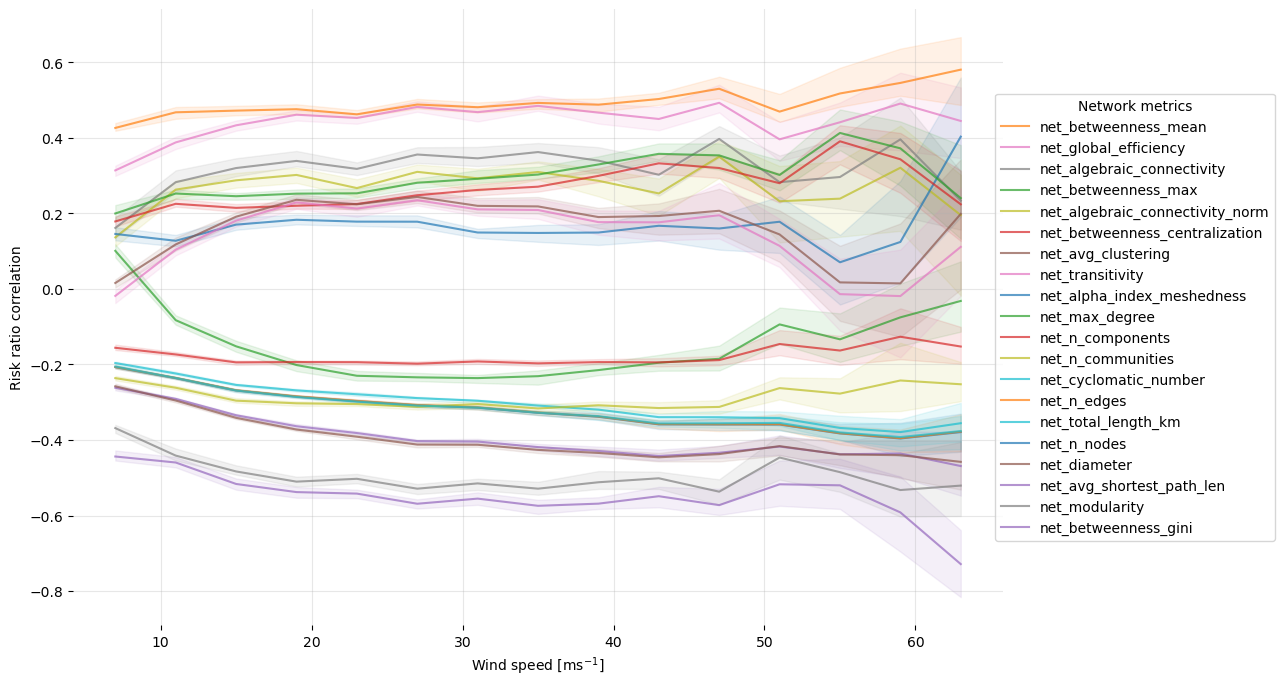

In [ ]:
def bootstrap_corr(x, y, n_boot=2000, ci=95, rng=None):
    rng = np.random.default_rng(rng)
    pair = pd.DataFrame({"x": x, "y": y}).dropna()
    n = len(pair)
    if n < 4:
        return np.nan, np.nan, np.nan
    x = pair["x"].to_numpy()
    y = pair["y"].to_numpy()
    r = np.corrcoef(x, y)[0, 1]
    # Indices of bootstrap samples: (n_boot, n)
    idx = rng.integers(0, n, size=(n_boot, n))
    xb = x[idx]
    yb = y[idx]
    xb = xb - xb.mean(axis=1, keepdims=True)
    yb = yb - yb.mean(axis=1, keepdims=True)
    numerator = np.sum(xb * yb, axis=1)
    denominator = np.sqrt(
        np.sum(xb**2, axis=1) *
        np.sum(yb**2, axis=1)
    )
    bootstrap_r = numerator / denominator
    alpha = (100 - ci) / 2
    return (
        r,
        np.nanpercentile(bootstrap_r, alpha),
        np.nanpercentile(bootstrap_r, 100 - alpha),
    )

table = df.select_dtypes(include=np.number)

start = 5
end = 65
n_bins = 15
n_boot = 50
r_min = 0.15
edges = np.linspace(start, end, n_bins + 1)
rng = np.random.default_rng(42)
rows = []
target = "pop_at_risk_ratio"
for lower, upper in zip(edges[:-1], edges[1:]):
    x = table[(table["wind_exceedance_ms-1"] >= lower) & (table["wind_exceedance_ms-1"] < upper)]
    center = (lower + upper) / 2
    row = {"wind_speed": center}
    for col in table.columns:
        if col in {target, "wind_exceedance_ms-1"}:
            continue
        r, lo, hi = bootstrap_corr(x[col], x[target], n_boot=n_boot, ci=95, rng=rng)
        row[f"{col}_r"] = r
        row[f"{col}_lo"] = lo
        row[f"{col}_hi"] = hi
        row[f"{col}_n"] = x[[col, target]].dropna().shape[0]
    rows.append(row)

results = pd.DataFrame(rows).set_index("wind_speed")

try_plotting = [c for c in table.columns if c.startswith("net_")]
fig, ax = plt.subplots(figsize=(12, 8))
plotted = []
for col in try_plotting:
    r = results[f"{col}_r"]
    if np.abs(np.median(r)) < r_min:
        continue
    lo = results[f"{col}_lo"]
    hi = results[f"{col}_hi"]
    line, = ax.plot(r.index, r, label=col, alpha=0.7)
    ax.fill_between(r.index, lo, hi, color=line.get_color(), alpha=0.1)
    plotted.append(col)

ax.set_xlabel("Wind speed [ms$^{-1}$]")
ax.set_ylabel("Risk ratio correlation")
ax.grid(which="both", alpha=0.3)
ax.set_frame_on(False)
legend_order = results[[f"{c}_r" for c in plotted]].median().sort_values(ascending=False)
# Strip "_r" to recover column names
legend_order = [c[:-2] for c in legend_order.index]
handles, labels = ax.get_legend_handles_labels()
lookup = dict(zip(labels, handles))
ax.legend(
    [lookup[c] for c in legend_order],
    legend_order,
    fontsize=10,
    title="Network metrics",
    loc="center right",
    bbox_to_anchor=(1.3, 0.5),
)

fig.savefig("risk_vs_network_metrics_bootstrap.png", bbox_inches="tight")